In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import boto3
import os
from tqdm import tqdm
import s3fs
import joblib
import warnings
warnings.filterwarnings('ignore')

try:
    import seaborn as sns
except:
    ! pip install seaborn
    import seaborn as sns

try:
    from prophet import Prophet
except:
    ! pip install prophet
    from prophet import Prophet

try:
    import optuna
    from optuna.samplers import TPESampler
except:
    ! pip install optuna
    import optuna
    from optuna.samplers import TPESampler

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

## Helper Classes

In [2]:
class ProphetModel:
    """Facebook Prophet model with Optuna hyperparameter tuning."""
    
    def __init__(self, str_bucket, str_dirname_output):
        self.str_bucket = str_bucket
        self.str_dirname_output = str_dirname_output
        self.fs = s3fs.S3FileSystem()
        self.s3_client = boto3.client('s3')
        self.df_train = None
        self.df_valid = None
        self.df_test = None
        self.df_train_prophet = None
        self.df_valid_prophet = None
        self.df_test_prophet = None
        self.model = None
        self.forecast_result = None
        self.dict_best_params = None
        self.study = None
    
    def import_data(self):
        """Load train/validation/test splits from S3."""
        str_train_uri = f's3://{self.str_bucket}/02_preprocessing/train_data.csv'
        str_valid_uri = f's3://{self.str_bucket}/02_preprocessing/valid_data.csv'
        str_test_uri = f's3://{self.str_bucket}/02_preprocessing/test_data.csv'
        
        self.df_train = pd.read_csv(str_train_uri)
        self.df_valid = pd.read_csv(str_valid_uri)
        self.df_test = pd.read_csv(str_test_uri)
        
        self.df_train['date'] = pd.to_datetime(self.df_train['date'])
        self.df_valid['date'] = pd.to_datetime(self.df_valid['date'])
        self.df_test['date'] = pd.to_datetime(self.df_test['date'])
        
        print(f'Loaded train: {len(self.df_train)} samples')
        print(f'Loaded validation: {len(self.df_valid)} samples')
        print(f'Loaded test: {len(self.df_test)} samples')
        
        return self.df_train, self.df_valid, self.df_test
    
    def prepare_data(self):
        """Format data for Prophet (ds, y columns)."""
        self.df_train_prophet = self.df_train[['date', 'attrition_rate']].copy()
        self.df_train_prophet.columns = ['ds', 'y']
        
        self.df_valid_prophet = self.df_valid[['date', 'attrition_rate']].copy()
        self.df_valid_prophet.columns = ['ds', 'y']
        
        self.df_test_prophet = self.df_test[['date', 'attrition_rate']].copy()
        self.df_test_prophet.columns = ['ds', 'y']
        
        print(f'Prepared data for Prophet:')
        print(f'  Train: {len(self.df_train_prophet)} samples')
        print(f'  Validation: {len(self.df_valid_prophet)} samples')
        print(f'  Test: {len(self.df_test_prophet)} samples')
        
        return self.df_train_prophet, self.df_valid_prophet, self.df_test_prophet
    
    def _objective(self, trial):
        """Optuna objective function for hyperparameter tuning."""
        flt_changepoint_prior_scale = trial.suggest_float('changepoint_prior_scale', 0.001, 0.5)
        flt_seasonality_prior_scale = trial.suggest_float('seasonality_prior_scale', 0.01, 10.0)
        str_seasonality_mode = trial.suggest_categorical('seasonality_mode', ['additive', 'multiplicative'])
        
        try:
            model = Prophet(
                changepoint_prior_scale=flt_changepoint_prior_scale,
                seasonality_prior_scale=flt_seasonality_prior_scale,
                seasonality_mode=str_seasonality_mode,
                yearly_seasonality=True,
                interval_width=0.95
            )
            
            model.fit(self.df_train_prophet)
            
            # Evaluate on test set
            df_forecast_valid = model.predict(self.df_valid_prophet[['ds']])
            arr_actual = self.df_valid_prophet['y'].values
            arr_pred = df_forecast_valid['yhat'].values
            
            flt_mape = np.mean(np.abs((arr_actual - arr_pred) / arr_actual))
            
            return flt_mape
        except:
            return float('inf')
    
    def optuna_search(self, int_n_trials=20):
        """Use Optuna to search hyperparameter space."""
        print(f'\nTuning Prophet with Optuna ({int_n_trials} trials)...')
        
        # Create study with TPESampler
        sampler = TPESampler(seed=42)
        self.study = optuna.create_study(
            sampler=sampler,
            direction='minimize'
        )
        
        # Optimize
        self.study.optimize(self._objective, n_trials=int_n_trials, show_progress_bar=True)
        
        # Get best params
        self.dict_best_params = self.study.best_params
        
        print(f'\nOptuna Search Complete!')
        print(f'Best parameters:')
        for str_key, str_val in self.dict_best_params.items():
            print(f'  {str_key}: {str_val}')
        print(f'Best MAPE: {self.study.best_value:.4f}')
        
        # Display top trials
        df_trials = self.study.trials_dataframe()
        df_trials_sorted = df_trials.sort_values('value').head(5)
        print(f'\nTop 5 trials:')
        print(df_trials_sorted[['number', 'value', 'params_changepoint_prior_scale', 'params_seasonality_prior_scale', 'params_seasonality_mode']].to_string(index=False))
        
        return df_trials
    
    def fit_model(self):
        """Fit Prophet with best parameters on train+validation."""
        print(f'\nFitting Prophet with best parameters on train+validation...')
        
        # Combine train and validation for final model
        df_train_valid_prophet = pd.concat([self.df_train_prophet, self.df_valid_prophet], ignore_index=True)
        
        self.model = Prophet(
            changepoint_prior_scale=self.dict_best_params['changepoint_prior_scale'],
            seasonality_prior_scale=self.dict_best_params['seasonality_prior_scale'],
            seasonality_mode=self.dict_best_params['seasonality_mode'],
            yearly_seasonality=True,
            interval_width=0.95
        )
        
        self.model.fit(df_train_valid_prophet)
        print('Model fitted successfully!')
        
        return self.model
    
    def forecast(self, int_periods=12):
        """Generate forecast."""
        df_future = self.model.make_future_dataframe(periods=int_periods, freq='MS')
        self.forecast_result = self.model.predict(df_future)
        
        # Extract forecast for future periods
        # Extract forecast for periods beyond train+validation
        dt_last_train_valid = max(self.df_train_prophet['ds'].max(), self.df_valid_prophet['ds'].max())
        df_forecast = self.forecast_result[self.forecast_result['ds'] > dt_last_train_valid][['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
        df_forecast.columns = ['date', 'forecast', 'ci_lower', 'ci_upper']
        
        print(f'\nGenerated {int_periods}-step forecast')
        print(df_forecast.head(10))
        
        return df_forecast
    
    def plot_forecast(self, df_forecast):
        """Plot forecast using Prophet's built-in plotting."""
        # Prophet default plot
        fig = self.model.plot(self.forecast_result)
        fig.suptitle('Prophet Forecast', fontsize=14, fontweight='bold', y=1.00)
        plt.tight_layout()
        
        str_path = f'{self.str_dirname_output}/13_prophet_forecast_default.png'
        fig.savefig(str_path, bbox_inches='tight', dpi=150)
        print(f'Saved default plot to {str_path}')
        plt.show()
        
        # Custom overlay plot
        fig, ax = plt.subplots(figsize=(14, 7))
        
        # Training data
        ax.plot(self.df_train_prophet['ds'], self.df_train_prophet['y'], linewidth=2, 
               label='Training Data', marker='o', markersize=4)
        
        # Test data
        ax.plot(self.df_test_prophet['ds'], self.df_test_prophet['y'], linewidth=2, 
               label='Test Data', marker='s', markersize=4, color='#ff7f0e')
        
        # Forecast
        ax.plot(df_forecast['date'], df_forecast['forecast'], linewidth=2.5, 
               label='Prophet Forecast', marker='^', markersize=5, color='#d62728')
        
        # Confidence intervals
        ax.fill_between(df_forecast['date'], df_forecast['ci_lower'], df_forecast['ci_upper'],
                        alpha=0.3, color='#d62728', label='95% Confidence Interval')
        
        ax.set_xlabel('Date', fontsize=11)
        ax.set_ylabel('Attrition Rate', fontsize=11)
        ax.set_title('Prophet Forecast vs Actual', fontsize=13, fontweight='bold')
        ax.legend(loc='best', fontsize=10)
        ax.grid(True, alpha=0.3)
        plt.xticks(rotation=45)
        plt.tight_layout()
        
        str_path = f'{self.str_dirname_output}/14_prophet_forecast_custom.png'
        plt.savefig(str_path, bbox_inches='tight', dpi=150)
        print(f'Saved custom plot to {str_path}')
        plt.show()
    
    def plot_components(self):
        """Plot trend and seasonality components."""
        fig = self.model.plot_components(self.forecast_result)
        fig.suptitle('Prophet Components (Trend and Seasonality)', fontsize=14, fontweight='bold')
        plt.tight_layout()
        
        str_path = f'{self.str_dirname_output}/15_prophet_components.png'
        fig.savefig(str_path, bbox_inches='tight', dpi=150)
        print(f'Saved components plot to {str_path}')
        plt.show()
    
    def evaluate(self, df_forecast):
        """Calculate RMSE, MAE, MAPE on test set."""
        arr_actual = self.df_test_prophet['y'].values
        arr_pred = df_forecast['forecast'].values[:len(arr_actual)]
        
        flt_rmse = np.sqrt(np.mean((arr_actual - arr_pred) ** 2))
        flt_mae = np.mean(np.abs(arr_actual - arr_pred))
        flt_mape = np.mean(np.abs((arr_actual - arr_pred) / arr_actual)) * 100
        
        dict_metrics = {
            'RMSE': flt_rmse,
            'MAE': flt_mae,
            'MAPE': flt_mape
        }
        
        print(f'\nTest Set Evaluation:')
        print(f'  RMSE: {flt_rmse:.6f}')
        print(f'  MAE: {flt_mae:.6f}')
        print(f'  MAPE: {flt_mape:.2f}%')
        
        return dict_metrics
    
    def save_model(self):
        """Serialize model to disk and S3."""
        str_model_path = f'{self.str_dirname_output}/prophet_model.pkl'
        joblib.dump(self.model, str_model_path)
        
        try:
            self.s3_client.upload_file(
                str_model_path,
                self.str_bucket,
                '04_prophet/prophet_model.pkl'
            )
            print(f'Saved model to {str_model_path} and S3')
        except Exception as e:
            print(f'Error uploading to S3: {e}')

## Constants

In [3]:
str_bucket = 'time-series-forecasting-demo'
str_task = 'employee_attrition_forecasting'
str_dirname_output = './output'

## Output Directory

In [4]:
try:
    os.mkdir(str_dirname_output)
except FileExistsError:
    pass

print(f'Output directory: {str_dirname_output}')

Output directory: ./output


## Load data

In [6]:
prophet_model = ProphetModel(str_bucket, str_dirname_output)
df_train, df_valid, df_test = prophet_model.import_data()

Loaded train: 48 samples
Loaded validation: 12 samples
Loaded test: 12 samples


In [7]:
df_train

,date,headcount,new_hires,departures,attrition_rate,avg_tenure_months,avg_satisfaction_score
0,2020-01-01,4544,705,686,0.151490,39.574227,7.103333
1,2020-01-31,4536,737,709,0.152697,40.776099,7.144393
2,2020-03-01,4570,546,554,0.117528,47.304553,7.200532
3,2020-03-31,4442,550,529,0.115409,41.572898,7.180251
4,2020-04-30,4451,512,494,0.106330,44.398178,6.717739
5,2020-05-30,4499,472,449,0.101233,42.774684,6.534091
6,2020-06-29,4505,381,357,0.076328,44.629461,7.709531
7,2020-07-29,4474,321,335,0.076421,38.959565,7.260049
8,2020-08-28,4465,466,415,0.089941,42.666650,6.891383
9,2020-09-27,4345,644,596,0.136549,46.852306,6.391925


In [8]:
df_valid

,date,headcount,new_hires,departures,attrition_rate,avg_tenure_months,avg_satisfaction_score
0,2023-12-11,4624,435,413,0.091907,46.278037,6.440812
1,2024-01-10,4579,709,691,0.145197,41.826638,7.068201
2,2024-02-09,4638,739,704,0.146091,42.828255,6.994236
3,2024-03-10,4519,518,531,0.113962,39.805681,7.054604
4,2024-04-09,4535,545,520,0.110223,42.974978,6.761841
5,2024-05-09,4556,512,496,0.106033,42.898346,6.765619
6,2024-06-08,4548,382,370,0.077874,41.704505,6.961203
7,2024-07-08,4590,351,324,0.070643,40.354087,6.911492
8,2024-08-07,4654,395,395,0.084176,40.783875,7.126485
9,2024-09-06,4648,634,589,0.125541,43.004886,6.868504


In [9]:
df_test

,date,headcount,new_hires,departures,attrition_rate,avg_tenure_months,avg_satisfaction_score
0,2024-12-05,4496,492,446,0.094206,40.761716,7.014290
1,2025-01-04,4566,719,719,0.153480,38.886842,7.248555
2,2025-02-03,4549,657,640,0.135840,42.846596,7.841359
3,2025-03-05,4467,586,546,0.120267,37.931673,7.101528
4,2025-04-04,4623,485,475,0.100799,40.504860,6.622151
5,2025-05-04,4576,478,451,0.100968,44.721990,6.941815
6,2025-06-03,4569,354,343,0.074768,44.019060,7.136780
7,2025-07-03,4625,344,334,0.072719,42.300419,7.027890
8,2025-08-02,4585,444,440,0.092368,38.182424,7.468765
9,2025-09-01,4494,614,601,0.130019,42.470115,6.800370


## Prepare Data

In [10]:
df_train_prophet, df_valid_prophet, df_test_prophet = prophet_model.prepare_data()

Prepared data for Prophet:
  Train: 48 samples
  Validation: 12 samples
  Test: 12 samples


In [11]:
df_train_prophet

,ds,y
0,2020-01-01,0.151490
1,2020-01-31,0.152697
2,2020-03-01,0.117528
3,2020-03-31,0.115409
4,2020-04-30,0.106330
5,2020-05-30,0.101233
6,2020-06-29,0.076328
7,2020-07-29,0.076421
8,2020-08-28,0.089941
9,2020-09-27,0.136549


In [12]:
df_valid_prophet

,ds,y
0,2023-12-11,0.091907
1,2024-01-10,0.145197
2,2024-02-09,0.146091
3,2024-03-10,0.113962
4,2024-04-09,0.110223
5,2024-05-09,0.106033
6,2024-06-08,0.077874
7,2024-07-08,0.070643
8,2024-08-07,0.084176
9,2024-09-06,0.125541


In [13]:
df_test_prophet

,ds,y
0,2024-12-05,0.094206
1,2025-01-04,0.153480
2,2025-02-03,0.135840
3,2025-03-05,0.120267
4,2025-04-04,0.100799
5,2025-05-04,0.100968
6,2025-06-03,0.074768
7,2025-07-03,0.072719
8,2025-08-02,0.092368
9,2025-09-01,0.130019


## Hyperparameter Tuning with Optuna

In [14]:
study = prophet_model.optuna_search(int_n_trials=20)

[I 2026-03-21 22:29:42,704] A new study created in memory with name: no-name-757fedd2-c2cd-4407-9ba2-1a20c7a10769



Tuning Prophet with Optuna (20 trials)...


  0%|          | 0/20 [00:00<?, ?it/s]

22:29:42 - cmdstanpy - INFO - Chain [1] start processing
22:29:43 - cmdstanpy - INFO - Chain [1] done processing
22:29:43 - cmdstanpy - INFO - Chain [1] start processing


[I 2026-03-21 22:29:43,059] Trial 0 finished with value: 0.28325465119405907 and parameters: {'changepoint_prior_scale': 0.1878955193048339, 'seasonality_prior_scale': 9.507635921035062, 'seasonality_mode': 'additive'}. Best is trial 0 with value: 0.28325465119405907.


...

[I 2026-03-21 22:29:48,607] Trial 16 finished with value: 0.26899050581570594 and parameters: {'changepoint_prior_scale': 0.44326509460995234, 'seasonality_prior_scale': 6.4621058426253795, 'seasonality_mode': 'multiplicative'}. Best is trial 11 with value: 0.26810840183743556.


22:29:49 - cmdstanpy - INFO - Chain [1] done processing
22:29:49 - cmdstanpy - INFO - Chain [1] start processing


[I 2026-03-21 22:29:49,196] Trial 17 finished with value: 0.2759481506391899 and parameters: {'changepoint_prior_scale': 0.3581543106151148, 'seasonality_prior_scale': 2.4028990096069722, 'seasonality_mode': 'multiplicative'}. Best is trial 11 with value: 0.26810840183743556.


22:29:49 - cmdstanpy - INFO - Chain [1] done processing
22:29:49 - cmdstanpy - INFO - Chain [1] start processing
22:29:49 - cmdstanpy - INFO - Chain [1] done processing


[I 2026-03-21 22:29:49,647] Trial 18 finished with value: 0.2696581586894149 and parameters: {'changepoint_prior_scale': 0.49582447009212105, 'seasonality_prior_scale': 4.459754072130595, 'seasonality_mode': 'multiplicative'}. Best is trial 11 with value: 0.26810840183743556.
[I 2026-03-21 22:29:49,880] Trial 19 finished with value: 0.27599441577853606 and parameters: {'changepoint_prior_scale': 0.35627692330449234, 'seasonality_prior_scale': 2.7030259765782594, 'seasonality_mode': 'multiplicative'}. Best is trial 11 with value: 0.26810840183743556.

Optuna Search Complete!
Best parameters:
  changepoint_prior_scale: 0.4763679871234113
  seasonality_prior_scale: 3.4668923930835964
  seasonality_mode: multiplicative
Best MAPE: 0.2681

Top 5 trials:
 number    value  params_changepoint_prior_scale  params_seasonality_prior_scale params_seasonality_mode
     11 0.268108                        0.476368                        3.466892          multiplicative
     13 0.268116                

## Fit Prophet Model

In [15]:
model = prophet_model.fit_model()

22:29:51 - cmdstanpy - INFO - Chain [1] start processing



Fitting Prophet with best parameters on train+validation...


22:29:51 - cmdstanpy - INFO - Chain [1] done processing


Model fitted successfully!


## Generate Forecast

In [16]:
df_forecast = prophet_model.forecast(int_periods=12)


Generated 12-step forecast
         date  forecast  ci_lower  ci_upper
60 2024-12-01  0.093902  0.045181  0.141763
61 2025-01-01  0.112408  0.065390  0.157591
62 2025-02-01  0.133730  0.082336  0.183736
63 2025-03-01  0.106591  0.060398  0.152567
64 2025-04-01  0.099249  0.050020  0.147012
65 2025-05-01  0.094707  0.048096  0.140808
66 2025-06-01  0.094682  0.044462  0.142933
67 2025-07-01  0.057790  0.008958  0.108247
68 2025-08-01  0.070157  0.022605  0.115349
69 2025-09-01  0.086740  0.036813  0.134380


## Plot Forecast

Saved default plot to ./output/13_prophet_forecast_default.png


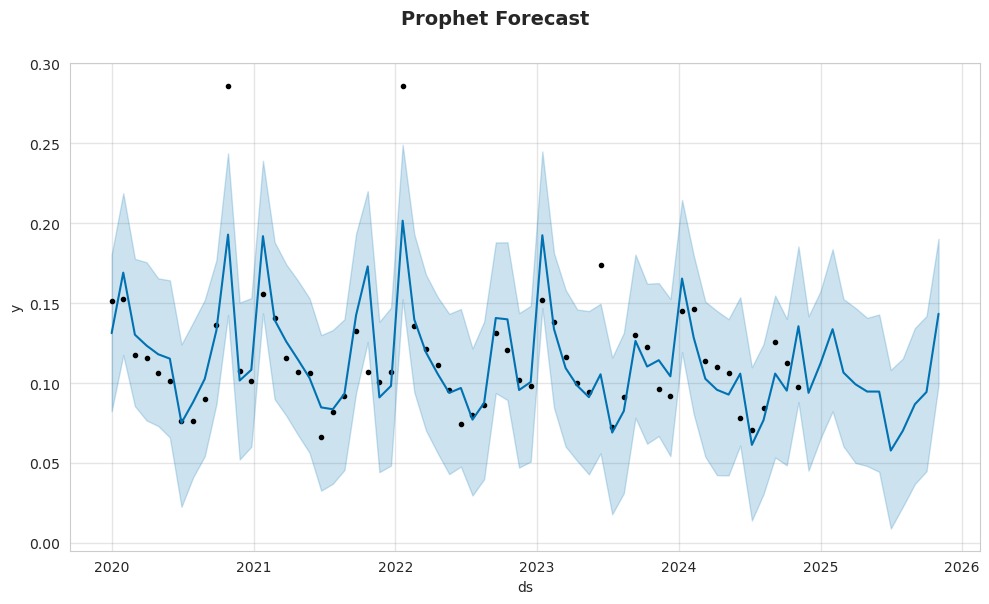

Saved custom plot to ./output/14_prophet_forecast_custom.png


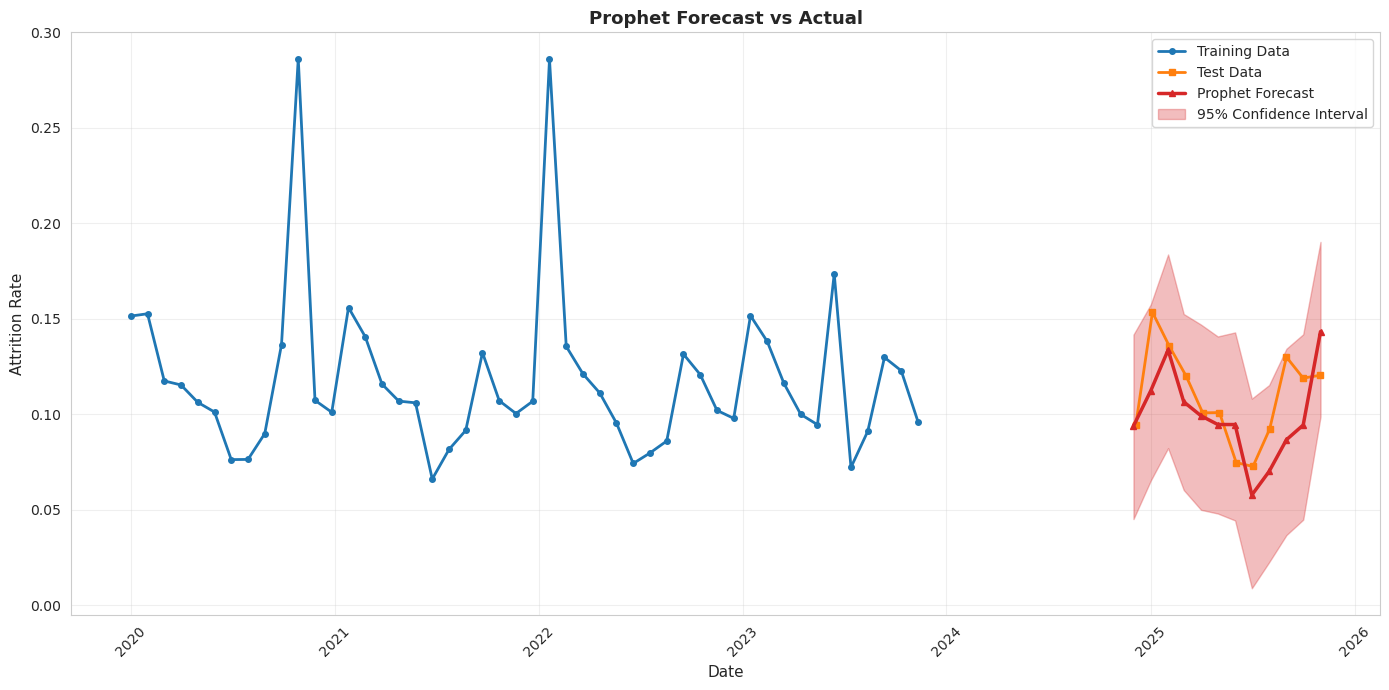

In [17]:
prophet_model.plot_forecast(df_forecast)

## Plot Components

Saved components plot to ./output/15_prophet_components.png


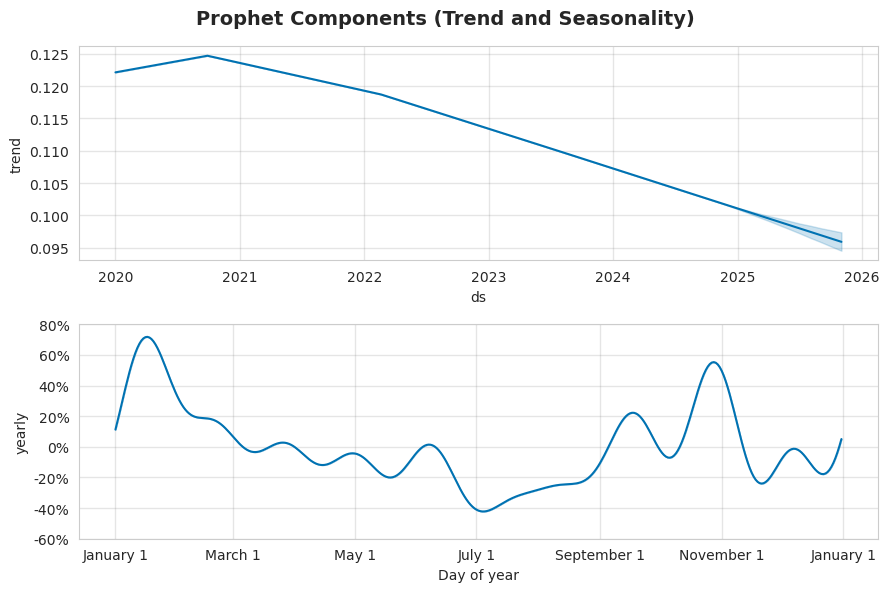

In [18]:
prophet_model.plot_components()

## Evaluate Model

In [19]:
dict_metrics = prophet_model.evaluate(df_forecast)


Test Set Evaluation:
  RMSE: 0.022423
  MAE: 0.017730
  MAPE: 15.99%


## Save Model

In [20]:
prophet_model.save_model()

Saved model to ./output/prophet_model.pkl and S3


## Model Summary

In [21]:
print(f'\n=== PROPHET MODEL SUMMARY ===')
print(f'Changepoint Prior Scale: {prophet_model.dict_best_params["changepoint_prior_scale"]:.4f}')
print(f'Seasonality Prior Scale: {prophet_model.dict_best_params["seasonality_prior_scale"]:.4f}')
print(f'Seasonality Mode: {prophet_model.dict_best_params["seasonality_mode"]}')
print(f'Test RMSE: {dict_metrics["RMSE"]:.6f}')
print(f'Test MAE: {dict_metrics["MAE"]:.6f}')
print(f'Test MAPE: {dict_metrics["MAPE"]:.2f}%')
print(f'\nModel ready for production deployment!')


=== PROPHET MODEL SUMMARY ===
Changepoint Prior Scale: 0.4764
Seasonality Prior Scale: 3.4669
Seasonality Mode: multiplicative
Test RMSE: 0.022423
Test MAE: 0.017730
Test MAPE: 15.99%

Model ready for production deployment!
